In [5]:
%pip install -q libreyolo matplotlib
%pip install -q --upgrade jupyter ipywidgets


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
from pathlib import Path


from libreyolo import LibreYOLO
IMAGE_SIZE = 640
BATCH_SIZE = 16


xFormers not available
xFormers not available


In [10]:
model = LibreYOLO("runs/train/delcolab/weights/best.pt")

In [11]:
import cv2
import numpy as np

video_path = "samples/288312_tiny.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")


In [2]:

# Define a region of interest in image coordinates.
roi_pts = np.array(
    [[200, 180], [900, 180], [900, 500], [200, 500]],
    dtype=np.int32,
)
roi_pts = roi_pts.reshape((-1, 1, 2))

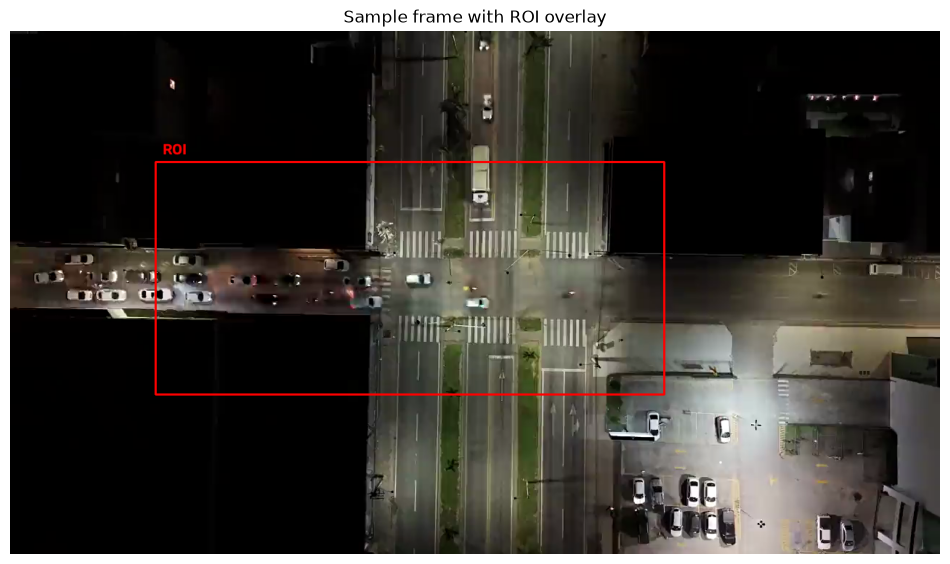

True

In [6]:
import matplotlib.pyplot as plt

# Ensure the video starts from the first frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

success, sample_frame = cap.read()
if not success:
    raise RuntimeError("Could not read a sample frame from the video.")

# Copy and draw the ROI on top of the sample frame
preview = sample_frame.copy()
cv2.polylines(preview, [roi_pts], isClosed=True, color=(0, 0, 255), thickness=2)
cv2.putText(
    preview,
    "ROI",
    (roi_pts[0][0][0] + 10, roi_pts[0][0][1] - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (0, 0, 255),
    2,
)

# Display it in the notebook
preview_rgb = cv2.cvtColor(preview, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(preview_rgb)
plt.title("Sample frame with ROI overlay")
plt.axis("off")
plt.show()

# Reset the video so the next cell can process from the beginning
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

In [12]:


allowed_classes = {"car", "bus", "lorry", "bicycle"}
frame_count = 0
counts = {name: 0 for name in sorted(allowed_classes)}
playback_speed = 2.0  # 2x slower than original video speed
frame_wait_ms = max(1, int((1000 / 30) * playback_speed))

while True:
    success, frame = cap.read()
    if not success:
        break

    results = model.predict(
        source=frame,
        imgsz=IMAGE_SIZE,
        conf=0.25,
        verbose=False,
    )

    result = results[0] if len(results) > 0 else None
    boxes = getattr(result, "boxes", None) if result is not None else None
    names = getattr(result, "names", getattr(model, "names", {})) if result is not None else getattr(model, "names", {})

    frame_detections = 0

    if boxes is not None:
        xyxy = boxes.xyxy
        confs = boxes.conf
        class_ids = boxes.cls

        if len(xyxy) > 0:
            for box, confidence, class_id in zip(xyxy.tolist(), confs.tolist(), class_ids.tolist()):
                class_id = int(class_id)
                class_name = names[class_id] if isinstance(names, (list, tuple)) else names.get(class_id, str(class_id))
                class_name = class_name.lower()

                if class_name not in allowed_classes:
                    continue

                x1, y1, x2, y2 = map(int, box)
                cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
                in_roi = cv2.pointPolygonTest(roi_pts, (int(cx), int(cy)), False) >= 0

                if in_roi:
                    counts[class_name] += 1
                    frame_detections += 1

                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    frame,
                    f"{class_name} {confidence:.2f}",
                    (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2,
                )

    cv2.polylines(frame, [roi_pts], isClosed=True, color=(0, 0, 255), thickness=2)
    cv2.putText(
        frame,
        f"ROI count: {frame_detections} | total={sum(counts.values())}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 0, 255),
        2,
    )
    cv2.imshow("YOLOv9 ROI counting", frame)
    key = cv2.waitKey(frame_wait_ms) & 0xFF
    if key == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

print("ROI counts by class:", counts)
print("Total in ROI:", sum(counts.values()))

/Users/luis/Proyectos/gdl-atsc-anti-spillback/.venv/lib/python3.13/site-packages/libreyolo/models/base/cuda_graph.py:467: UserWarning: Predict option 'verbose' is accepted for CLI compatibility but is currently a no-op in LibreYOLO.
  return predict_fn(self, *args, **kwargs)


ROI counts by class: {'bicycle': 0, 'bus': 0, 'car': 7, 'lorry': 14}
Total in ROI: 21
